data zip from [here](https://f000.backblazeb2.com/file/jeldridge-data/016-socal/data.zip)  
  
delete ".zip" file since we aren't given the test set

In [1]:
from pathlib import Path

data_fp = Path("data")

In [2]:
import os
import torch
from PIL import Image
import torchvision.transforms as transforms

_dir = os.getcwd()
_dir

raw_X = list()
raw_y = list()
i = 1
for image_path in os.listdir("data"):
    # print(image_path)
    curr_path = _dir + "\\data\\" + image_path

    img = Image.open(curr_path)
    tens = transforms.ToTensor()(img)
    raw_X.append(tens)

    label = image_path.split("-")[0]
    raw_y.append(label)

    if i % (len(list(os.listdir("data"))) // 10) == 0:
        print(f"iteration {i}")
    i+=1

print(f"{len(raw_X)} images and labels")
curr_path

iteration 918
iteration 1836
iteration 2754
iteration 3672
iteration 4590
iteration 5508
iteration 6426
iteration 7344
iteration 8262
iteration 9180
9181 images and labels


'c:\\Users\\seani\\OneDrive\\Desktop\\DSC 140B\\dsc140b_final_project\\data\\SLO-ffe9583f.jpg'

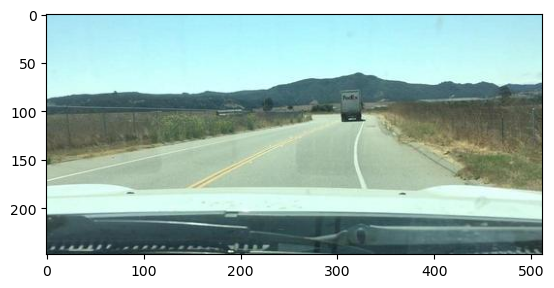

In [3]:
import matplotlib.pyplot as plt

plt.imshow(img)

In [4]:
from sklearn.preprocessing import OneHotEncoder

X = torch.stack(raw_X, dim=0) 

raw_y = [[city] for city in raw_y]

ohe = OneHotEncoder()
ohe.fit(raw_y)

y = ohe.transform(raw_y).toarray()
y = torch.tensor(y, dtype=torch.float32)
print(y.shape)
y

torch.Size([9181, 6])


tensor([[1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0.],
        ...,
        [0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 1., 0.]])

In [5]:
n_training_samples = 1000
X_train, X_test = X[:n_training_samples], X[n_training_samples:]
y_train, y_test = y[:n_training_samples], y[n_training_samples:]

X_train.shape, y_train.shape, X_test.shape, y_test.shape

(torch.Size([1000, 3, 248, 512]),
 torch.Size([1000, 6]),
 torch.Size([8181, 3, 248, 512]),
 torch.Size([8181, 6]))

In [17]:
from torch import nn

_, ic, _, oc = X.shape
model = nn.Sequential(
    nn.Conv2d(in_channels=ic, out_channels=oc, kernel_size=3, stride=1),
    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Linear(oc, 512),
    nn.ReLU(),
    nn.Linear(512,128),
    nn.ReLU(),
    nn.Linear(128, 6)
)

# model(X_train).shape

In [18]:
from torch.utils.data import DataLoader, TensorDataset
train_dataset = TensorDataset(X_train, y_train)

batch_size=16
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
device = "cuda" if torch.cuda.is_available() else "cpu"

print(X_train.shape, y_train.shape)
X_train.dtype, y_train.dtype

torch.Size([1000, 3, 248, 512]) torch.Size([1000, 6])


(torch.float32, torch.float32)

In [19]:
from torch.nn import CrossEntropyLoss
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

loss_fn = CrossEntropyLoss()

def train_one_epoch(epoch_index, tb_writer):
    cum_loss = 0
    prev_loss = 0

    for i, data in enumerate(train_dataloader):
        inputs, labels = data

        optim.zero_grad()
        print(inputs.shape)
        preds = model(inputs)
        print(preds.shape, labels.shape)
        loss = loss_fn(preds, labels)
        loss.backward()
        optim.step()

        cum_loss += loss.item()
        print(i)
        break
        if i % 1000 == 0:
            prev_loss = cum_loss/1000
            print(f"Batch {i+1} - Avg. Loss = {prev_loss}")
            tb_x = epoch_index * len(train_dataloader) + i + 1
            tb_writer.add_scalar("Loss/train", prev_loss, tb_x)
            cum_loss = 0

    return prev_loss


lr = 10**-3
optim = torch.optim.SGD(model.parameters(), lr=lr)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
writer = SummaryWriter('runs/fashion_trainer_{}'.format(timestamp))
epoch_number = 0

epochs = 1
best_validation_loss = torch.inf

for epoch in range(epochs):
    model.train(True)
    avg_loss = train_one_epoch(epoch_number, writer)




torch.Size([16, 3, 248, 512])
torch.Size([16, 6]) torch.Size([16, 6])
0
